In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import os
import re

In [2]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', None)  # Show all columns
# pd.set_option('display.max_rows', None)     # Show all rows
# pd.set_option('display.max_colwidth', None) # Show entire content of each column
pd.set_option('display.width', None)        # No limit on display width
pd.set_option('display.expand_frame_repr', False)  # Prevent wrapping

In [3]:
df = pd.read_csv("dataframe.csv")
df.head(20)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
5,2579,132,6,300,-15,67,230,237,140,6031,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2
6,2606,45,7,270,5,633,222,225,138,6256,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
7,2605,49,4,234,7,573,222,230,144,6228,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
8,2617,45,9,240,56,666,223,221,133,6244,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
9,2612,59,10,247,11,636,228,219,124,6230,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Soil_Type1                          581012 non-null 

In [5]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,0.448865,0.051434,0.436074,0.063627,0.005217,0.012952,0.008301,0.021335,0.002749,0.011316,0.000181,0.000308,0.001974,0.056168,0.021359,0.051584,0.030001,0.001031,0.000005,0.004897,0.005890,0.003268,0.006921,0.015936,0.001442,0.057439,0.099399,0.036622,0.000816,0.004456,0.001869,0.001628,0.198356,0.051927,0.044175,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,0.497379,0.220882,0.495897,0.244087,0.072039,0.113066,0.090731,0.144499,0.052356,0.105775,0.013442,0.017550,0.044387,0.230245,0.144579,0.221186,0.170590,0.032092,0.002272,0.069804,0.076518,0.057077,0.082902,0.125228,0.037950,0.232681,0.299197,0.187833,0.028551,0.066605,0.043193,0.040318,0.398762,0.221879,0.205483,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000

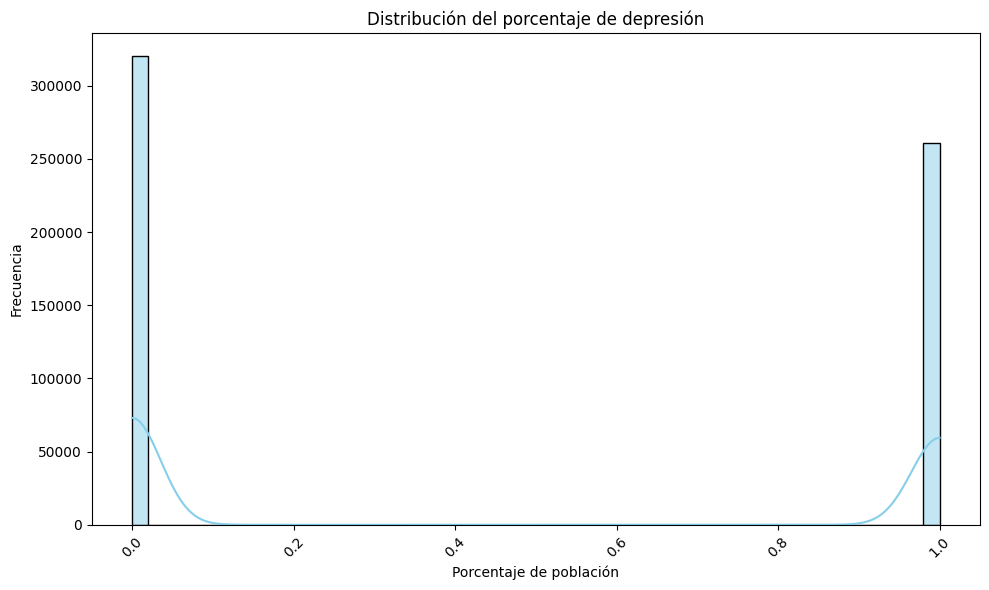

In [8]:
df_data = pd.read_csv("dataframe.csv")

# 2. Preprocesamiento: convierte la columna a numérica si es necesario
df_clean_data = df_data.copy()
col_name = 'Wilderness_Area1'
df_clean_data[col_name] = pd.to_numeric(df_clean_data[col_name], errors='coerce')

# 3. Genera el gráfico
plt.figure(figsize=(10, 6))
sns.histplot(df_clean_data[col_name], bins=50, kde=True, color='skyblue')
plt.title('Distribución del porcentaje de depresión')
plt.xlabel('Porcentaje de población')
plt.ylabel('Frecuencia')

# Solo si los valores son numéricos muy grandes o pequeños:
# plt.ticklabel_format(axis='x', style='plain')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


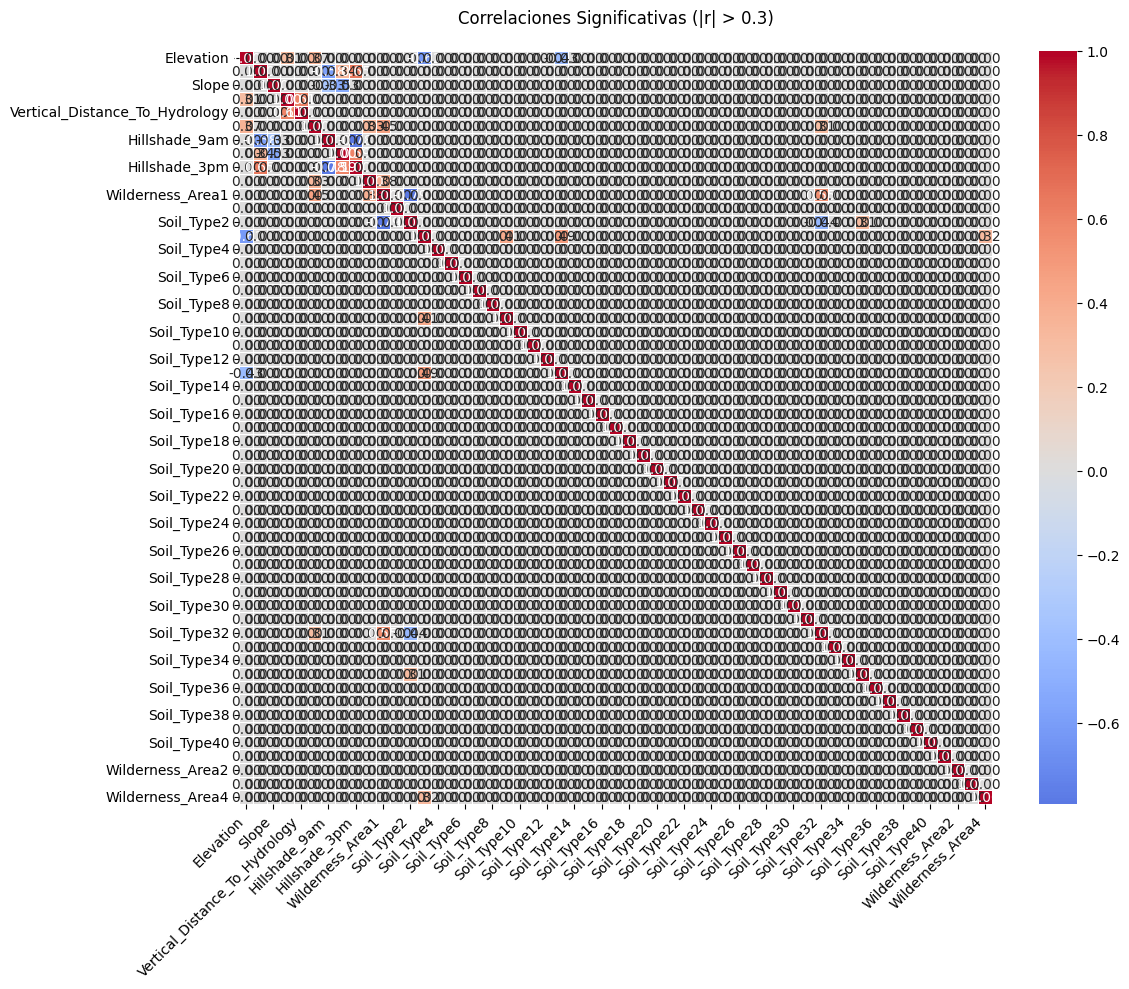

In [12]:
# Filtrar solo correlaciones importantes (abs(corr) > 0.3)
significant_corr = corr_matrix.copy()
significant_corr[(significant_corr.abs() < 0.3) & (significant_corr.abs() > 0)] = 0

plt.figure(figsize=(12, 10))
sns.heatmap(significant_corr,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Correlaciones Significativas (|r| > 0.3)', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Definir las listas de nombres de columnas (esto ya lo tenías en tu EDA original)
columnas_cuantitativas = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                          'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                          'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                          'Horizontal_Distance_To_Fire_Points']

wilderness_areas = ['Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3',
                    'Wilderness_Area_4']

soil_types = [f'Soil_Type_{i}' for i in range(1, 41)]

target_variable = 'Cover_Type'

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Separar X e y
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar características cuantitativas
scaler = StandardScaler()
X_train[columnas_cuantitativas] = scaler.fit_transform(X_train[columnas_cuantitativas])
X_test[columnas_cuantitativas] = scaler.transform(X_test[columnas_cuantitativas])

# Manejar el desbalance de clases con SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Tamaño del conjunto de entrenamiento después de SMOTE:", X_train_resampled.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento después de SMOTE: (904728, 54)
Tamaño del conjunto de prueba: (116203, 54)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

# Regresión Logística Multiclase
logreg = LogisticRegression(multi_class='ovr', solver='liblinear', random_state=42, max_iter=100)  # 'ovr' para multiclase
logreg.fit(X_train_resampled, y_train_resampled)
y_pred_logreg = logreg.predict(X_test)
print("Regresión Logística Multiclase:\n", classification_report(y_test, y_pred_logreg))

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=20)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test)
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

# Gradient Boosting Machine
gbm = GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1)
gbm.fit(X_train_resampled, y_train_resampled)
y_pred_gbm = gbm.predict(X_test)
print("Gradient Boosting Machine:\n", classification_report(y_test, y_pred_gbm))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Regresión Logística Multiclase:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    113075
           1       1.00      1.00      1.00      3128

    accuracy                           1.00    116203
   macro avg       1.00      1.00      1.00    116203
weighted avg       1.00      1.00      1.00    116203

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    113075
           1       0.99      1.00      0.99      3128

    accuracy                           1.00    116203
   macro avg       1.00      1.00      1.00    116203
weighted avg       1.00      1.00      1.00    116203

Gradient Boosting Machine:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    113075
           1       0.96      1.00      0.98      3128

    accuracy                           1.00    116203
   macro avg       0.98      1.00      0.99    1162

In [19]:
# Cargamos el dataset
df = pd.read_csv("dataframe.csv")

# Definimos los nombres de las columnas
columnas_cuantitativas = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

columnas_wilderness = [f'Wilderness_Area_{i}' for i in range(1, 5)]

columnas_soil = [f'Soil_Type_{i}' for i in range(1, 41)]

columna_target = ['Cover_Type']

todas_columnas = columnas_cuantitativas + columnas_wilderness + columnas_soil + columna_target

df.columns = todas_columnas

Dimensiones del dataset: (581012, 55)

Distribución de clases:
Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64


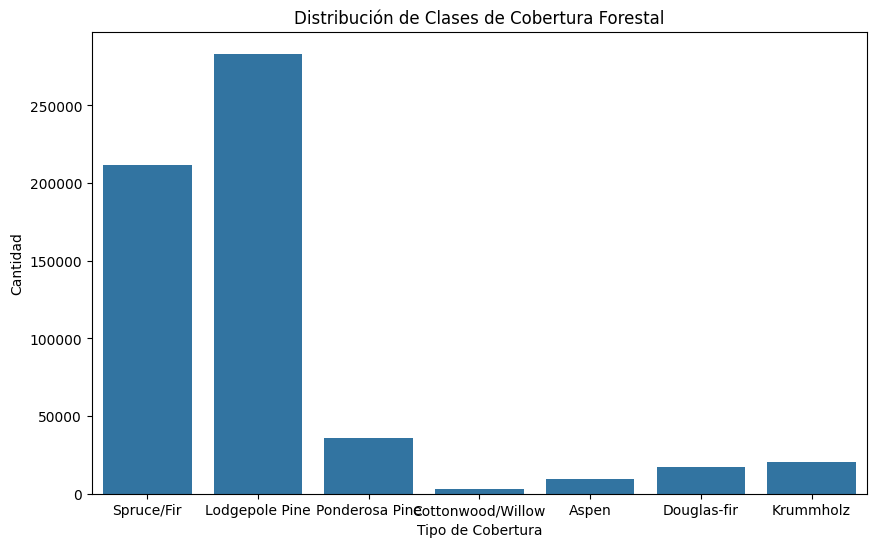

In [20]:
# Información básica del dataset
print("Dimensiones del dataset:", df.shape)
print("\nDistribución de clases:")
print(df['Cover_Type'].value_counts())

# Visualizamos la distribución de clases
plt.figure(figsize=(10, 6))
sns.countplot(x='Cover_Type', data=df)
plt.title('Distribución de Clases de Cobertura Forestal')
plt.xlabel('Tipo de Cobertura')
plt.ylabel('Cantidad')
plt.xticks(ticks=range(7), labels=['Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
                                 'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz'])
plt.show()

In [22]:
# Separamos características y variable objetivo
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

# Define the RANDOM_STATE variable
RANDOM_STATE = 42 # You can use any integer value

# Dividimos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 464809 muestras
Tamaño del conjunto de prueba: 116203 muestras


In [23]:
# Escalamos solo las variables cuantitativas
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columnas_cuantitativas] = scaler.fit_transform(X_train[columnas_cuantitativas])
X_test_scaled[columnas_cuantitativas] = scaler.transform(X_test[columnas_cuantitativas])

# Verificamos el resultado del escalado
print("Estadísticas después del escalado (variables cuantitativas):")
print(X_train_scaled[columnas_cuantitativas].describe().loc[["mean", "std"]].round(2))

Estadísticas después del escalado (variables cuantitativas):
      Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  Hillshade_9am  Hillshade_Noon  Hillshade_3pm  Horizontal_Distance_To_Fire_Points
mean       -0.0     0.0   -0.0                               0.0                             0.0                             -0.0           -0.0            -0.0            0.0                                 0.0
std         1.0     1.0    1.0                               1.0                             1.0                              1.0            1.0             1.0            1.0                                 1.0


In [24]:
# Debido al tamaño del dataset, vamos a usar una muestra para entrenar modelos iniciales
# Esto nos permitirá comparar rápidamente diferentes algoritmos

# Tomamos una muestra estratificada del 10% para evaluación inicial
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, y_train, test_size=0.9, random_state=RANDOM_STATE, stratify=y_train
)

print(f"Tamaño de la muestra para evaluación inicial: {X_train_sample.shape[0]} muestras")

Tamaño de la muestra para evaluación inicial: 46480 muestras


In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# Definimos los modelos a evaluar
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE)
}

# Evaluamos cada modelo con validación cruzada
results = {}

for name, model in models.items():
    print(f"Evaluando {name}...")
    # Usamos validación cruzada con 3 folds para evaluar el rendimiento
    cv_scores = cross_val_score(model, X_train_sample, y_train_sample, cv=3, scoring='accuracy')
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    print(f"  Precisión media CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

Evaluando Random Forest...
  Precisión media CV: 0.8604 (±0.0009)
Evaluando Gradient Boosting...
  Precisión media CV: 0.7686 (±0.0030)
Evaluando SVM...
  Precisión media CV: 0.7830 (±0.0023)


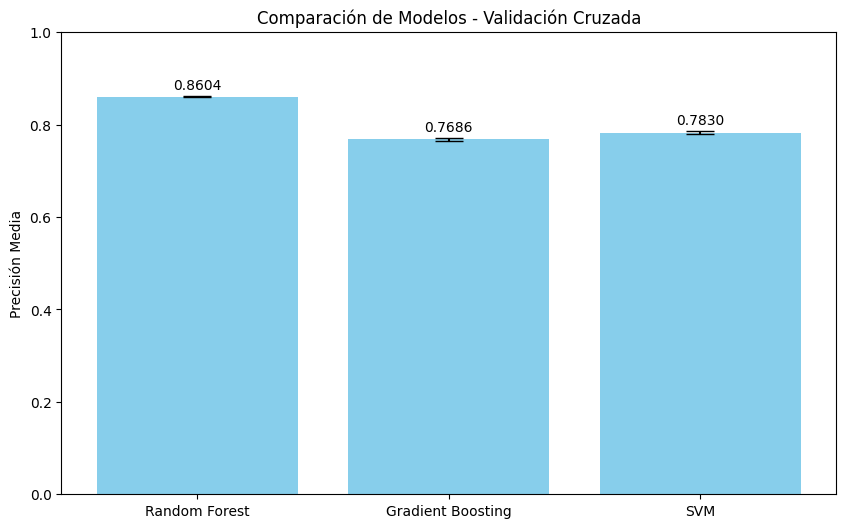

In [27]:
# Visualizamos los resultados de la evaluación inicial
plt.figure(figsize=(10, 6))
models_names = list(results.keys())
cv_means = [results[name]['cv_mean'] for name in models_names]
cv_stds = [results[name]['cv_std'] for name in models_names]

bars = plt.bar(models_names, cv_means, yerr=cv_stds, capsize=10, color='skyblue')
plt.title('Comparación de Modelos - Validación Cruzada')
plt.ylabel('Precisión Media')
plt.ylim(0, 1.0)

# Añadimos etiquetas con los valores
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom')

plt.show()

In [29]:
# Definimos el modelo Random Forest para optimización
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)

# Definimos los hiperparámetros a optimizar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

from sklearn.model_selection import GridSearchCV # Import GridSearchCV

# Realizamos búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenamos el modelo con la muestra para encontrar los mejores hiperparámetros
grid_search.fit(X_train_sample, y_train_sample)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor puntuación CV: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor puntuación CV: 0.8631


In [31]:
# Entrenamos el modelo final con los mejores hiperparámetros en todo el conjunto de entrenamiento
best_rf_model = RandomForestClassifier(**grid_search.best_params_, random_state=RANDOM_STATE)
best_rf_model.fit(X_train_scaled, y_train)

# Evaluamos en el conjunto de prueba
y_pred = best_rf_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score # Import the accuracy_score function

# Calculamos la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")

Precisión en el conjunto de prueba: 0.9543


In [32]:
# Generamos el reporte de clasificación
print("Reporte de Clasificación:\n")
class_names = ['Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine', 'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz']
print(classification_report(y_test, y_pred, target_names=class_names))

Reporte de Clasificación:

                   precision    recall  f1-score   support

       Spruce/Fir       0.96      0.94      0.95     42368
   Lodgepole Pine       0.95      0.97      0.96     56661
   Ponderosa Pine       0.94      0.96      0.95      7151
Cottonwood/Willow       0.92      0.85      0.88       549
            Aspen       0.95      0.78      0.86      1899
      Douglas-fir       0.93      0.89      0.91      3473
        Krummholz       0.97      0.95      0.96      4102

         accuracy                           0.95    116203
        macro avg       0.95      0.91      0.92    116203
     weighted avg       0.95      0.95      0.95    116203



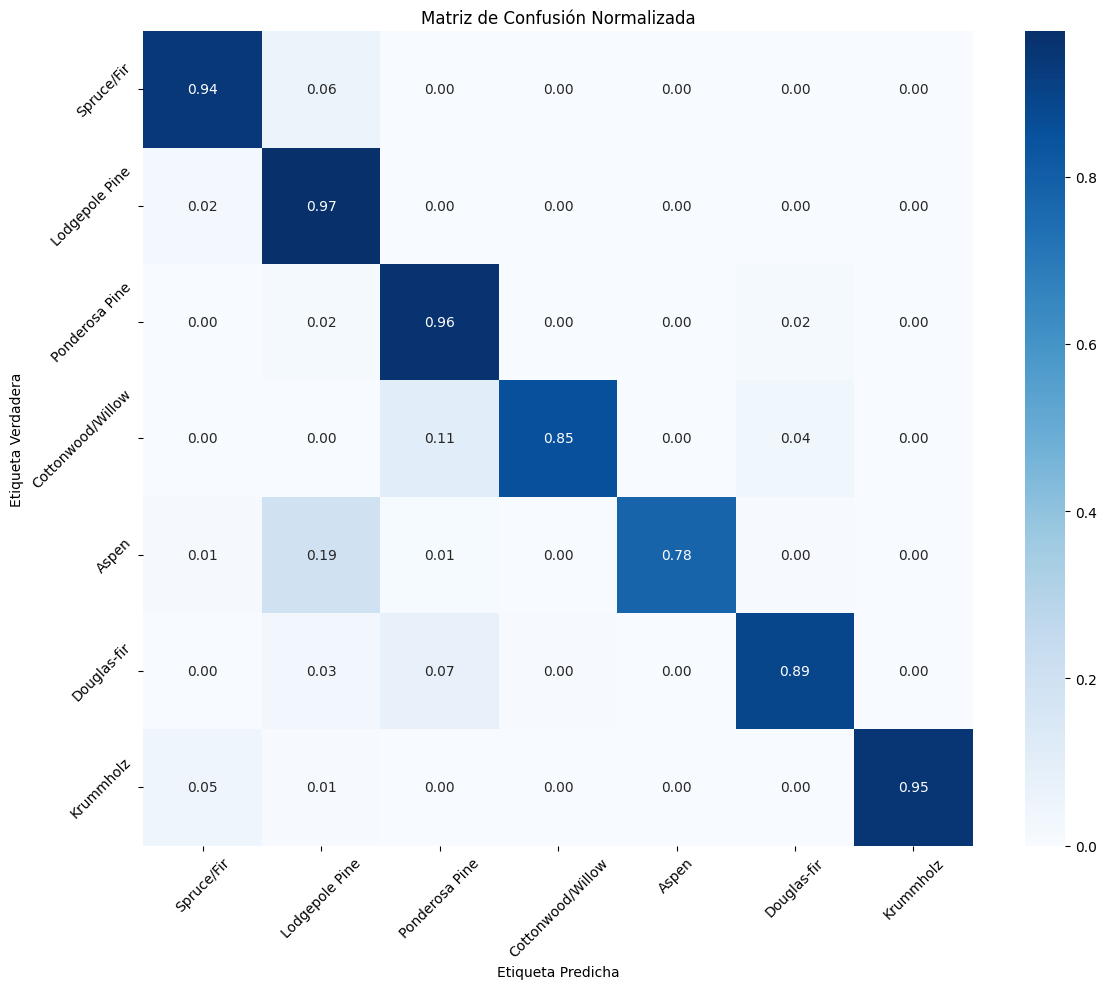

In [34]:
# Visualizamos la matriz de confusión
from sklearn.metrics import confusion_matrix # Import the confusion_matrix function

plt.figure(figsize=(12, 10))
conf_matrix = confusion_matrix(y_test, y_pred)

# Normalizamos la matriz para mejor visualización
conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión Normalizada')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()